# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Waqas Ahmed)_

**Roll Number:** _(023-24-0031)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
raw = pd.read_csv("telco_churn.csv", header=None)

# Split the single CSV column
df = raw[0].str.split(",", expand=True)

# Use the first row as column names
df.columns = df.iloc[0]

# Remove the header row from the actual data
df = df.iloc[1:].reset_index(drop=True)

print("Shape:", df.shape)
print(df.head())


Shape: (7043, 21)
0  customerID  gender SeniorCitizen Partner Dependents tenure PhoneService  \
0  7590-VHVEG  Female             0     Yes         No      1           No   
1  5575-GNVDE    Male             0      No         No     34          Yes   
2  3668-QPYBK    Male             0      No         No      2          Yes   
3  7795-CFOCW    Male             0      No         No     45           No   
4  9237-HQITU  Female             0      No         No      2          Yes   

0     MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

0 TechSupport StreamingTV StreamingMovies        Contrac

In [5]:
# Create cleaned dataframe
cleaned_df = df.copy()

# Convert numerical columns
cleaned_df["SeniorCitizen"] = pd.to_numeric(
    cleaned_df["SeniorCitizen"],
    errors="coerce"
)

cleaned_df["tenure"] = pd.to_numeric(
    cleaned_df["tenure"],
    errors="coerce"
)

cleaned_df["MonthlyCharges"] = pd.to_numeric(
    cleaned_df["MonthlyCharges"],
    errors="coerce"
)

cleaned_df["TotalCharges"] = pd.to_numeric(
    cleaned_df["TotalCharges"],
    errors="coerce"
)

# Remove rows where TotalCharges is missing
cleaned_df = cleaned_df.dropna(subset=["TotalCharges"])

# Remove duplicate rows
cleaned_df = cleaned_df.drop_duplicates()

print("Cleaned shape:", cleaned_df.shape)

Cleaned shape: (7032, 21)


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [30]:
# Task 4 — dataset shape, column names, data types
print("Shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)

Shape: (7044, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
customerID          str
gender              str
SeniorCitizen       str
Partner             str
Dependents          str
tenure              str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
MonthlyCharges      str
TotalCharges        str
Churn               str
dtype: object


In [31]:
# Task 5 — identify identifier columns / wrong data types
# Task 5
print("Data types:")
print(df.dtypes)

print("\nUnique values in customerID:", df["customerID"].nunique())
print("Number of rows:", len(df))
print("\nTotalCharges data type:", df["TotalCharges"].dtype)

Data types:
customerID          str
gender              str
SeniorCitizen       str
Partner             str
Dependents          str
tenure              str
PhoneService        str
MultipleLines       str
InternetService     str
OnlineSecurity      str
OnlineBackup        str
DeviceProtection    str
TechSupport         str
StreamingTV         str
StreamingMovies     str
Contract            str
PaperlessBilling    str
PaymentMethod       str
MonthlyCharges      str
TotalCharges        str
Churn               str
dtype: object

Unique values in customerID: 7044
Number of rows: 7044

TotalCharges data type: str


In [32]:
# Task 6 — unique values in 3 categorical columns
columns = ["gender", "Contract", "InternetService"]

for col in columns:
    print(f"\n{col}:")
    print(df[col].unique())
    print("Number of unique values:", df[col].nunique())


gender:
<StringArray>
['gender', 'Female', 'Male']
Length: 3, dtype: str
Number of unique values: 3

Contract:
<StringArray>
['Contract', 'Month-to-month', 'One year', 'Two year']
Length: 4, dtype: str
Number of unique values: 4

InternetService:
<StringArray>
['InternetService', 'DSL', 'Fiber optic', 'No']
Length: 4, dtype: str
Number of unique values: 4


**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [33]:
# Task 7 — missing values: count and percentage per column
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(missing_report)
print(missing_report[missing_report["Missing Count"] > 0])

                  Missing Count  Missing Percentage
customerID                    0                 0.0
gender                        0                 0.0
SeniorCitizen                 0                 0.0
Partner                       0                 0.0
Dependents                    0                 0.0
tenure                        0                 0.0
PhoneService                  0                 0.0
MultipleLines                 0                 0.0
InternetService               0                 0.0
OnlineSecurity                0                 0.0
OnlineBackup                  0                 0.0
DeviceProtection              0                 0.0
TechSupport                   0                 0.0
StreamingTV                   0                 0.0
StreamingMovies               0                 0.0
Contract                      0                 0.0
PaperlessBilling              0                 0.0
PaymentMethod                 0                 0.0
MonthlyCharg

In [34]:
# Task 8 — duplicate rows vs duplicate IDs

duplicate_rows = df.duplicated().sum()
duplicate_ids = df["customerID"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_ids)

print(df[df["customerID"].duplicated(keep=False)].sort_values("customerID"))

Duplicate rows: 0
Duplicate customer IDs: 0
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


In [35]:
# Task 9 — investigate a suspicious / invalid value
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


customerID:
customerID
customerID    1
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7044, dtype: int64

gender:
gender
Male      3555
Female    3488
gender       1
Name: count, dtype: int64

SeniorCitizen:
SeniorCitizen
0                5901
1                1142
SeniorCitizen       1
Name: count, dtype: int64

Partner:
Partner
No         3641
Yes        3402
Partner       1
Name: count, dtype: int64

Dependents:
Dependents
No            4933
Yes           2110
Dependents       1
Name: count, dtype: int64

tenure:
tenure
1         613
72        362
2         238
3         200
4         176
         ... 
39         56
44         51
36         50
0          11
tenure      1
Name: count, Length: 74, dtype: int64

PhoneService:
PhoneService
Yes             6361
No               682
PhoneService       1
Name: count, dtype: int64

MultipleLines:
MultipleLin

C:\Users\VICKY-PC\AppData\Local\Temp\ipykernel_4940\3410674318.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


**Answer 7 (which missing-value problems need action, and why):**
There are no missing values in the dataset. Every column has 0 missing values (0.0%), so no missing-value treatment is required.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
Duplicate rows and duplicate customer IDs are different issues. Duplicate rows mean the entire customer record is repeated, while duplicate IDs mean the same customer ID appears more than once. Both should be checked separately because duplicate IDs can occur even when the complete rows are different.

**Answer 9 (suspicious value found and how):**
A suspicious value can be found in the TotalCharges column because it represents a numerical amount but may be stored as text. I identified this by checking the column's data type and attempting to convert its values to numeric values.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| TotalCharges stored as text|Convert to numeric | pd.to_numeric() | It represents a monetary amount and should be numeric for analysis/modeling.|
| Missing values |No action required | df.isnull().sum() | No missing values were found in the dataset. |
| Duplicate rows| Remove only if found | df.drop_duplicates() | Duplicate records can bias analysis and modeling. |     

In [36]:
# Task 11 — apply your cleaning decisions here
cleaned_df = df.copy()

# 1. Convert TotalCharges to numeric
cleaned_df["TotalCharges"] = pd.to_numeric(
    cleaned_df["TotalCharges"],
    errors="coerce"
)

# 2. Remove completely duplicated rows
cleaned_df = cleaned_df.drop_duplicates()

print("Cleaned dataset shape:", cleaned_df.shape)

Cleaned dataset shape: (7044, 21)


In [40]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Total missing values:",
      cleaned_df.isnull().sum().sum())

print("\nMissing values by column:")
print(cleaned_df.isnull().sum())

print("\nDuplicate rows:",
      cleaned_df.duplicated().sum())

print("\nDuplicate customer IDs:",
      cleaned_df["customerID"].duplicated().sum())

print("\nTotalCharges data type:",
      cleaned_df["TotalCharges"].dtype)

Total missing values: 0

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Duplicate customer IDs: 0

TotalCharges data type: float64


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

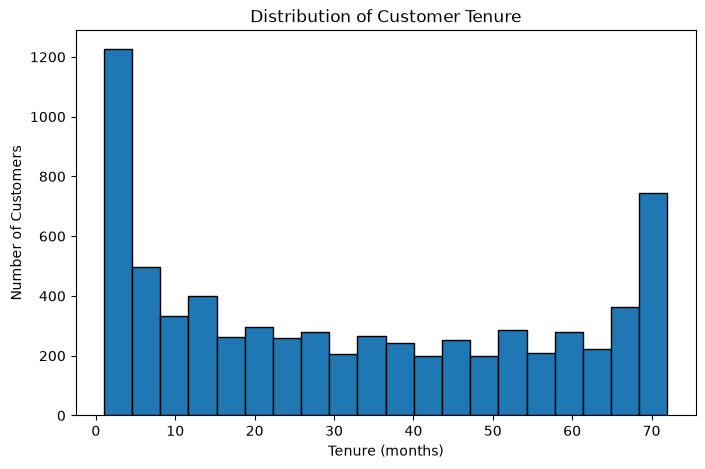

In [6]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(8, 5))

plt.hist(cleaned_df["tenure"], bins=20, edgecolor="black")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _(Customer tenure ranges from 0 to 72 months. The distribution is spread across the full range, with many customers having relatively short tenures and another noticeable concentration among long-term customers.)_

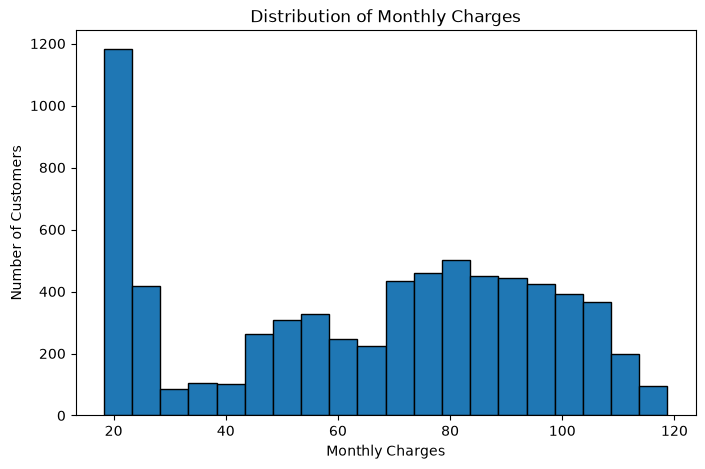

In [7]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df["MonthlyCharges"], bins=20, edgecolor="black")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

**Observation:** _(Monthly charges range from about $18 to $119, with many customers concentrated around the middle-to-higher charge range. The distribution is fairly balanced overall, although there are some variations in customer pricing.)_

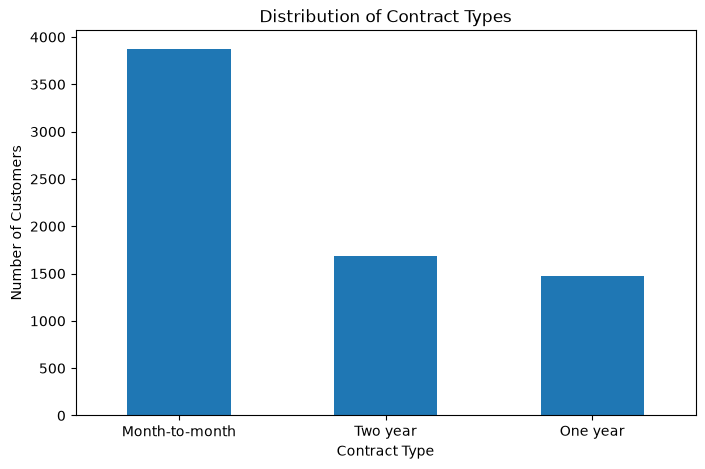

In [8]:
# Task 12 — categorical feature 1: distribution plot
contract_counts = cleaned_df["Contract"].value_counts()
plt.figure(figsize=(8, 5))
contract_counts.plot(kind="bar")
plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Observation:** _(Month-to-month contracts are the most common, with 3,875 customers, while one-year and two-year contracts have fewer customers. This shows that the dataset contains substantially more customers on flexible month-to-month contracts.)_

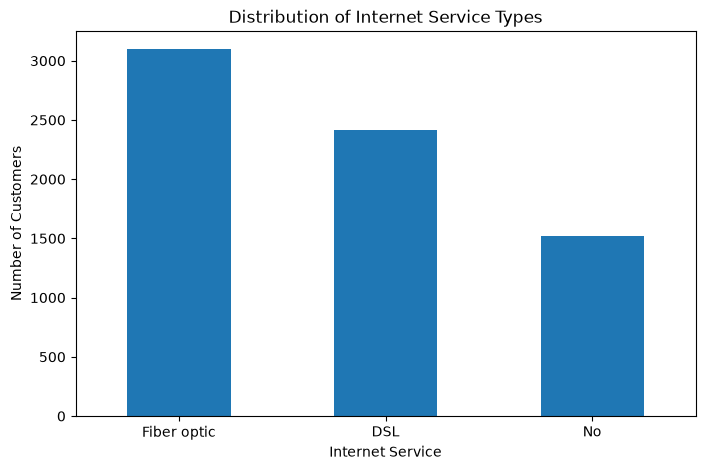

In [9]:
# Task 12 — categorical feature 2: distribution plot
internet_counts = cleaned_df["InternetService"].value_counts()
plt.figure(figsize=(8, 5))
internet_counts.plot(kind="bar")
plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

**Observation:** _(Fiber optic is the most common internet service with 3,096 customers, followed by DSL with 2,421 customers. A smaller group of 1,526 customers does not use an internet service.)_

**Answer 13 (outliers / skew and possible explanation):**
_(The tenure and MonthlyCharges distributions are relatively close to symmetric and do not show strong skewness. TotalCharges is more right-skewed, which is reasonable because customers who have stayed with the company longer can accumulate much larger total charges. The numerical variables do not show major extreme outliers based on the IQR check.e)_

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [10]:
# Task 14 — churn counts and percentages
churn_counts = cleaned_df["Churn"].value_counts()
churn_percentages = cleaned_df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print("\nChurn percentages:")
print(churn_percentages.round(2))

Churn counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


**Answer 14 (balanced or imbalanced?):**
_(The target variable is imbalanced. Approximately 73% of customers did not churn, while about 27% churned. Therefore, the two classes are not evenly represented.)_

**Answer 15 (why imbalance might matter later):**
_(Class imbalance matters because a classification model may perform well on the majority class while performing poorly on the minority class. In this dataset, a model could appear accurate by mostly predicting non-churn, while failing to correctly identify customers who actually churn.)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn percentage by contract type:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


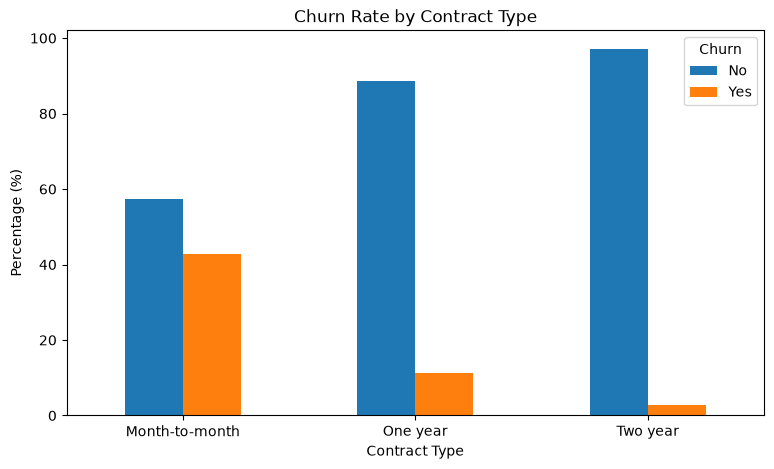

In [11]:
# Task 16 — categorical feature 1 vs Churn
contract_churn = pd.crosstab(
    cleaned_df["Contract"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by contract type:")
print(contract_churn.round(2))

# Plot
contract_churn.plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

**Customers with month-to-month contracts have a much higher churn rate than customers with one-year or two-year contracts.:** _..._
**Approximately 42.7% of month-to-month customers churned, compared with about 11.3% of one-year customers and 2.8% of two-year customers.:** _..._
**Month-to-month customers have greater flexibility to leave because they are not committed to a long-term contract. Longer contracts may encourage customers to remain with the company.:** _..._

Churn percentage by internet service:
Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


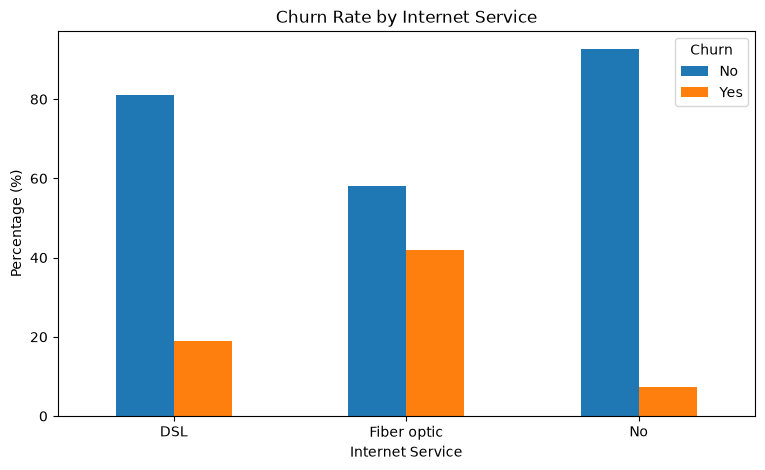

In [12]:
# Task 16 — categorical feature 2 vs Churn
internet_churn = pd.crosstab(
    cleaned_df["InternetService"],
    cleaned_df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by internet service:")
print(internet_churn.round(2))

# Plot
internet_churn.plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

**Customers using fiber optic internet have a substantially higher churn rate than customers using DSL or no internet service.:** _..._
**The churn rate is approximately 41.9% for fiber-optic customers, compared with about 19.0% for DSL customers and 7.4% for customers without internet service.:** _..._
**The higher churn among fiber-optic customers may be related to service expectations, pricing, competition, or customer dissatisfaction. However, this analysis shows an association and does not prove that fiber service itself causes churn.:** _..._

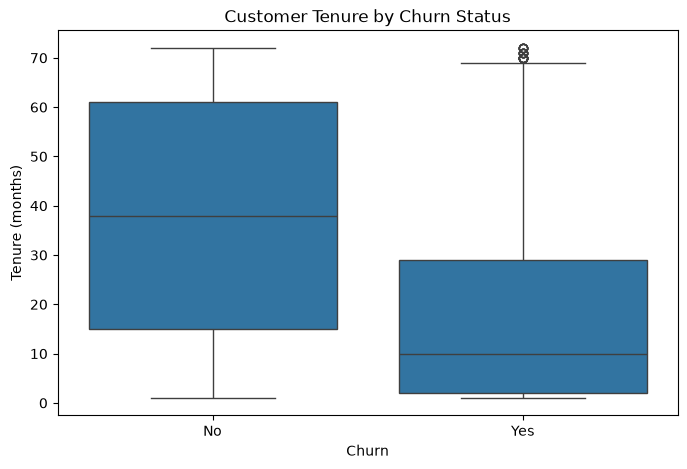

Tenure statistics by churn:
       count   mean  median  min  max
Churn                                
No      5163  37.65    38.0    1   72
Yes     1869  17.98    10.0    1   72


In [13]:
# Task 17 — numerical feature 1 vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=cleaned_df
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")

plt.show()

# Summary statistics
print("Tenure statistics by churn:")
print(
    cleaned_df.groupby("Churn")["tenure"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

**Customers who churn generally have shorter tenures than customers who remain with the company.:** _..._
**The average tenure of customers who churn is approximately 18 months, compared with about 38 months for customers who do not churn.:** _..._
**Newer customers may have weaker long-term relationships with the company and may be more willing to switch to another provider.:** _..._

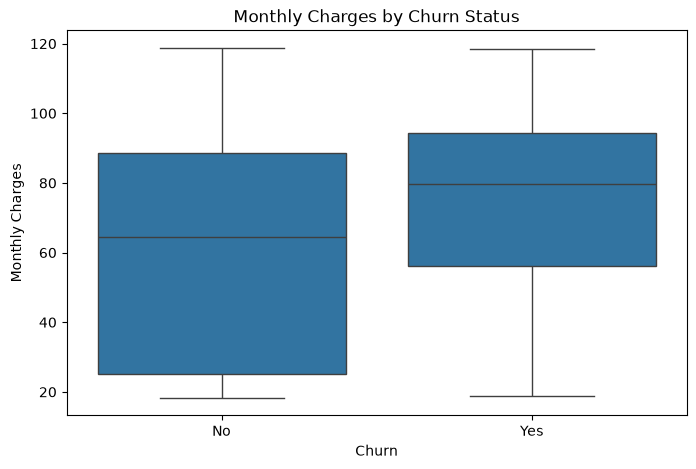

Monthly charges statistics by churn:
       count   mean  median    min     max
Churn                                     
No      5163  61.31   64.45  18.25  118.75
Yes     1869  74.44   79.65  18.85  118.35


In [14]:
# Task 17 — numerical feature 2 vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=cleaned_df
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

# Summary statistics
print("Monthly charges statistics by churn:")
print(cleaned_df.groupby("Churn")["MonthlyCharges"].agg(["count", "mean", "median", "min", "max"]).round(2))

**Observation: Customers who churn tend to have higher monthly charges than customers who remain.:** _..._
**Evidence: The average monthly charge is approximately $74 for customers who churn, compared with about $61 for customers who do not churn.:** _..._
**Possible Explanation: Higher monthly charges may make customers more sensitive to pricing or more likely to consider competing services. However, the relationship may also be influenced by other factors such as contract type and internet service.:** _..._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

In [ ]:
# Task 18 — correlation matrix and heatmap


**Answer 18 (most correlated pairs):**
_(your answer here)_

**Answer 19 (correlation vs. causation; potential problems):**
_(your answer here)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(your answer here)_

**Answer 21 (what would go wrong):**
_(your answer here)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | ... |
| tenure | Numerical | Feature | ... | ... |
| Contract | Categorical | Feature | ... | ... |
| Churn | Categorical | Target | Keep | ... |
| ... | ... | ... | ... | ... |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [ ]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 2**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 3**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 4**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 5**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(your answer here)_
2. What was the most interesting pattern you discovered?
   _(your answer here)_
3. Which feature seems most useful for predicting churn?
   _(your answer here)_
4. Which feature should probably not be used, and why?
   _(your answer here)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(your answer here)_
6. What would you do next if you had another 3 hours?
   _(your answer here)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook